# Ottimizzazione della Predizione del Churn nel settore Telecomunicazioni

**Corso:** Laboratorio di Ottimizzazione, Intelligenza Artificiale e Machine Learning  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Autori:** Diego Andruccioli, Rei Mici

---

Questo progetto è l'evoluzione diretta dell'analisi sviluppata nel corso di *Laboratorio di Big Data* ([repo precedente](https://github.com/diegoandruccioli/telco-churn-analysis)).  
Partendo da una Logistic Regression baseline (~79% accuracy), l'obiettivo è ottimizzare sistematicamente i modelli tramite Cross-Validation e Grid Search, e introdurre nuovi modelli: K-Nearest Neighbors (KNN) e Rete Neurale Artificiale (MLP).

---

## Executive Summary — Per il Lettore Non Tecnico

Questo progetto risponde a una domanda di business concreta:

> **"Riusciamo a prevedere quali clienti stanno per abbandonare il servizio, prima che lo facciano?"**

**Cosa significa *churn*?**  
Il termine *churn* indica l'abbandono del servizio da parte di un cliente. Nel settore delle telecomunicazioni, acquisire un nuovo cliente costa in media **5-7 volte in più** rispetto a mantenere un rapporto con un cliente già esistente. Identificare in anticipo i clienti a rischio permette all'azienda di intervenire con offerte mirate, riducendo il tasso di abbandono e proteggendo i ricavi.

**Cosa abbiamo fatto?**  
Inizialmente, abbiamo analizzato i dati di **7.043 clienti** di una compagnia telefonica, successivamente abbiamo costruito e confrontato quattro diversi modelli predittivi. Infine, abbiamo identificato il modello piu efficace nel rilevare i clienti a rischio.

**Risultato principale:**  
Il modello migliore sul Recall (KNN ottimizzato, soglia 0.35) identifica correttamente il **73% dei clienti che abbandoneranno** rispetto al 57% del modello di partenza. Su 374 clienti a rischio nel campione di test, ne intercettiamo correttamente ~273 invece dei ~213 iniziali — un miglioramento di **+16 punti percentuali** e circa 60 clienti in più salvati per ogni ciclo di previsione.

---

## Setup Ambiente, Librerie, Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, log_loss,
    make_scorer, recall_score
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42   # seed fisso: tutti i processi stocastici producono gli stessi risultati ad ogni esecuzione
THRESHOLD    = 0.35 # soglia di classificazione: abbassata da 0.5 per aumentare il Recall sulla classe churn

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# ~7043 clienti, 21 colonne: dati demografici, servizi attivati, tipo contratto e addebiti
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## 0. Punto di Partenza: Il Progetto Precedente

Riepilogo dei risultati ottenuti nel progetto precedente (Big Data), usati come **baseline** di confronto.

| Metrica | Valore (baseline) |
|---|---|
| Accuracy | ~79% |
| Recall (Churn=1) | ~56% |
| Tecnica | Logistic Regression, train/test split semplice |
| Clustering | K-Means (3 cluster), Elbow Method |

**Problema identificato:** con un Recall basso (~56%), quasi metà dei clienti a rischio non viene identificata. Un cliente churner non rilevato è un ricavo perso: rimpiazzarlo costa 5–7× di più che trattenerlo con un'offerta mirata. Ottimizzare il Recall è quindi la priorità di business.

## Introduzione del Problema

**Problema:** prevedere quali clienti di una società di telecomunicazioni abbandoneranno il servizio (*churn*) prima che lo facciano, per consentire interventi di retention mirati.

**Tipo di task:** classificazione binaria supervisionata — la variabile target  assume valore  (abbandono) o  (cliente attivo).

**Obiettivo:** ottimizzare il Recall (minimizzare i falsi negativi) tramite Cross-Validation K-Fold e Grid Search su quattro famiglie di modelli — Logistic Regression, Decision Tree, KNN e MLP — partendo da una baseline del progetto precedente (~79% accuracy, ~56% Recall).

**Interesse pratico:** nel settore Telco, acquisire un nuovo cliente costa in media **5–7 volte di più** rispetto a mantenerne uno esistente. Un sistema predittivo che identifica i clienti a rischio permette di ridurre il churn con offerte mirate, aumentando il valore del cliente nel tempo (CLV).

## Descrizione del Dataset

**Origine:** IBM Telco Customer Churn — disponibile pubblicamente su [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

**Dimensione:** 7.043 osservazioni × 21 colonne (20 feature + 1 target). Dopo la pulizia: `customerID` rimosso (solo identificatore), restano **19 feature + 1 target**.

**Variabile target:** `Churn` — binaria (Yes/No → 1/0). Distribuzione: ~73.5% No-Churn, ~26.5% Churn → **dataset sbilanciato**.

| Categoria | Variabili |
|---|---|
| Demografiche | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Contratto e durata | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| Servizi telefonici | `PhoneService`, `MultipleLines` |
| Servizi internet | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Addebiti | `MonthlyCharges`, `TotalCharges` |
| **Target** | **`Churn`** |

**Note:** `TotalCharges` contiene valori vuoti per clienti con `tenure=0` (imputati con la mediana). Le variabili categoriche binarie sono codificate con Label Encoding; `MultipleLines`, `InternetService`, `Contract` (e altri 7 servizi) con One-Hot Encoding (vedi §1.5).

## 1. Data Cleaning e Analisi Esplorativa (EDA)

### 1.1 Analisi dei dati

In [3]:
# Prima ispezione: capire i tipi di dato e identificare valori mancanti prima di qualsiasi operazione
print(df.dtypes)
print('\nValori nulli:')
print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Valori nulli:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMe

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


> **Statistiche descrittive:** `tenure` varia da 0 a 72 mesi (media ~32). `MonthlyCharges` va da ~18 a ~119 € (media ~65). `TotalCharges` ha alta varianza perché dipende dal prodotto `tenure × MonthlyCharges`. Queste differenze di scala motivano l'applicazione di `StandardScaler` in §1.5.

### 1.2 Conversione e pulizia dei dati

In [5]:
# TotalCharges arriva come stringa perchè i clienti con tenure=0 hanno campo vuoto -> conversione forzata
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# La mediana è più robusta della media quando la distribuzione è asimmetrica (gli outlier non la spostano)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# customerID è solo un identificatore: includerlo nel training causerebbe data leakage senza alcun valore predittivo
df.drop(columns=['customerID'], inplace=True)

print('Valori nulli dopo cleaning:', df.isnull().sum().sum())

Valori nulli dopo cleaning: 0


### 1.3 Analisi della variabile target (Churn)

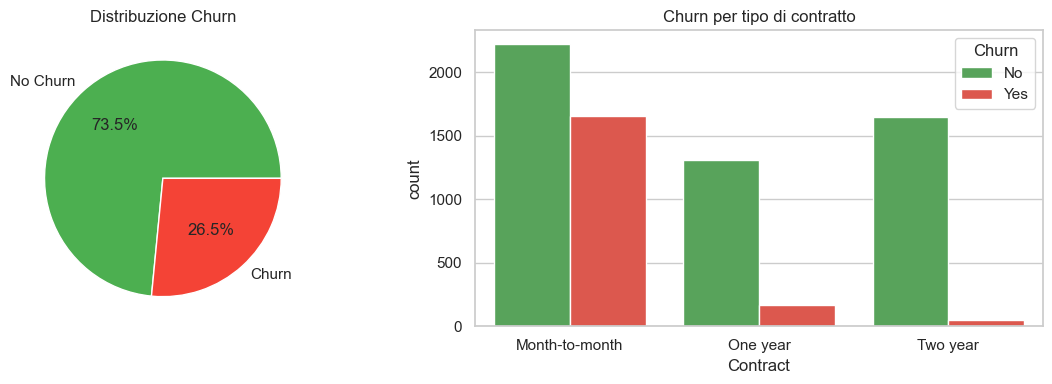

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Il dataset è sbilanciato (~26% churn): questa asimmetria giustifica la scelta del Recall come metrica target
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'])
axes[0].set_title('Distribuzione Churn')

# Il tipo di contratto è il predittore più forte: i clienti Month-to-Month abbandonano molto di più
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1],
              palette={'No': '#4CAF50', 'Yes': '#F44336'})
axes[1].set_title('Churn per tipo di contratto')

plt.tight_layout()
plt.show()

> **Lettura per il business:**  
> Su 7.043 clienti analizzati, **1.869 hanno abbandonato** il servizio (~26.6%). Questo squilibrio è rilevante: un modello che predice sempre "nessuno abbandona" ottiene il 73% di accuratezza — ma identifica zero churner. Per questo ottimizziamo il Recall (quanti veri churner trova il modello), non la semplice accuratezza. 
> Il grafico a destra conferma che i clienti con contratto **Month-to-Month** abbandonano molto più frequentemente: sono il target prioritario per le azioni di retention.

### 1.4 Analisi Fedeltà e Spesa

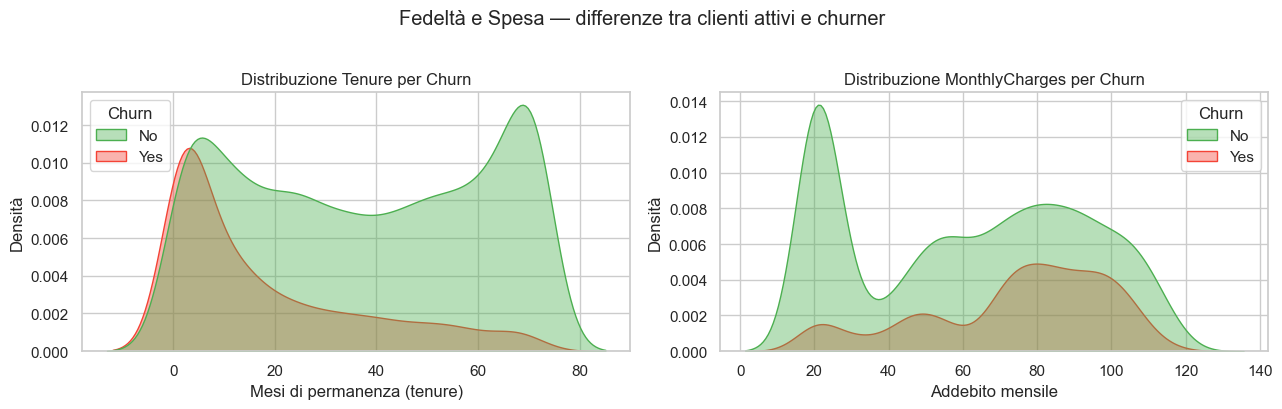

       tenure  MonthlyCharges
Churn                        
No       37.6            61.3
Yes      18.0            74.4


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# I clienti che abbandonano tendono ad avere una tenure bassa: il rischio di churn è concentrato nei primi mesi
# La distribuzione dei churner (rosso) è spostata verso sinistra rispetto ai clienti fedeli (verde)
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, alpha=0.4,
            palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[0])
axes[0].set_title("Distribuzione Tenure per Churn")
axes[0].set_xlabel("Mesi di permanenza (tenure)")
axes[0].set_ylabel("Densità")

# I clienti che abbandonano hanno in media addebiti mensili più elevati
# Causa probabile: piani costosi senza contratto a lungo termine (Month-to-Month)
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.4,
            palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[1])
axes[1].set_title("Distribuzione MonthlyCharges per Churn")
axes[1].set_xlabel("Addebito mensile")
axes[1].set_ylabel("Densità")

plt.suptitle("Fedeltà e Spesa — differenze tra clienti attivi e churner", y=1.02)
plt.tight_layout()
plt.show()

# Valori medi per confronto numerico: quantificano la differenza tra i due gruppi
print(df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(1))

> **Lettura per il business:**  
> **Grafico sinistra (Tenure):** i clienti che abbandonano sono prevalentemente nuovi — la curva rossa è spostata verso sinistra. Il rischio di abbandono è massimo nei **primi 6 mesi**: si suggerisce un intervento subito dopo l'acquisizione è più efficace che aspettare.  
> **Grafico destra (Addebito mensile):** i churner pagano mediamente di più. Probabile causa: i piani costosi vengono scelti da clienti senza contratto a lungo termine, che poi trovano offerte migliori altrove. Una strategia di retention mirata ai nuovi clienti ad alto valore ha impatto immediato sui ricavi.

### 1.5 Encoding e Feature Scaling

In [8]:
df_enc = df.copy()

# Label Encoding per variabili binarie (Yes/No, Male/Female): produce 0/1 senza creare colonne extra
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# One-Hot Encoding per variabili con più di 2 categorie: evita che il modello interpreti l'ordine numerico come significativo
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)
# pandas 2.x restituisce colonne bool -> conversione a int per compatibilita con sklearn
df_enc = df_enc.astype({col: int for col in df_enc.select_dtypes('bool').columns})

X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

# Il train/test split precede lo scaling: mu e sigma vengono calcolati esclusivamente
# su X_train ed applicati (transform) su X_test, evitando data leakage
# stratify=y: mantiene la stessa proporzione di churn (26%) sia nel train che nel test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# StandardScaler: porta tutte le feature sulla stessa scala (media 0, deviazione standard 1)
# Necessario per Logistic Regression e MLP: entrambi sensibili alla scala perchè ottimizzano tramite gradiente
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Feature: {X_train.shape[1]}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Feature: 30
Train: 5634 | Test: 1409


### 1.6 Analisi delle Correlazioni tra Feature

Heatmap delle correlazioni di Pearson sulle variabili numeriche codificate. Evidenzia le feature più associate al target `Churn` e le eventuali collinearità tra predittori.

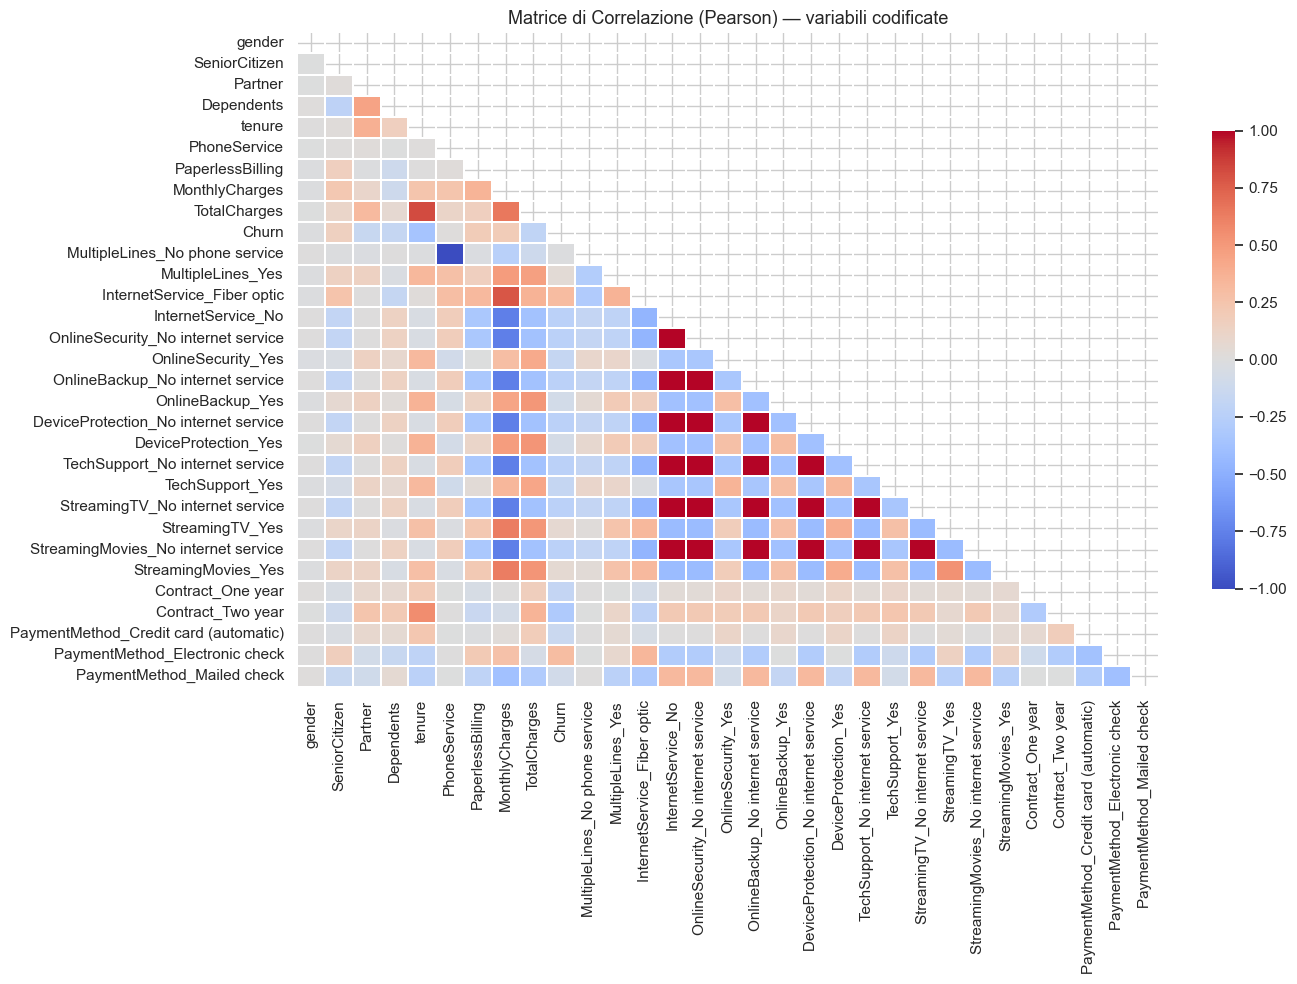

Top 10 feature per correlazione assoluta con Churn:
tenure                                  0.352
InternetService_Fiber optic             0.308
Contract_Two year                       0.302
PaymentMethod_Electronic check          0.302
InternetService_No                      0.228
OnlineSecurity_No internet service      0.228
DeviceProtection_No internet service    0.228
TechSupport_No internet service         0.228
StreamingMovies_No internet service     0.228
StreamingTV_No internet service         0.228
Name: Churn, dtype: float64


In [9]:
# Heatmap su variabili numeriche: evidenzia associazioni con Churn e collinearita tra feature
corr_matrix = df_enc.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Matrice di Correlazione (Pearson) — variabili codificate', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlazioni con Churn
churn_corr = corr_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)
print('Top 10 feature per correlazione assoluta con Churn:')
print(churn_corr.head(10).round(3))

> **Osservazioni:** `Contract` e `tenure` mostrano la correlazione negativa più forte con Churn — contratti lunghi e clienti anziani abbandonano meno. `MonthlyCharges` è positivamente correlata: clienti con addebiti alti sono più a rischio, probabilmente perché privi di vincoli contrattuali. `TotalCharges` e `tenure` sono fortemente correlate tra loro (collinearità attesa: TotalCharges ≈ tenure × MonthlyCharges) — lo `StandardScaler` non risolve la collinearità, ma i modelli regolarizzati (LR con C basso, DT con `max_depth`) la gestiscono implicitamente.

## 2. Outlier Detection Avanzata

### 2.1 Metodo classico: IQR / Box-plot

Rilevamento univariato sulle variabili numeriche continue (baseline dal progetto precedente).

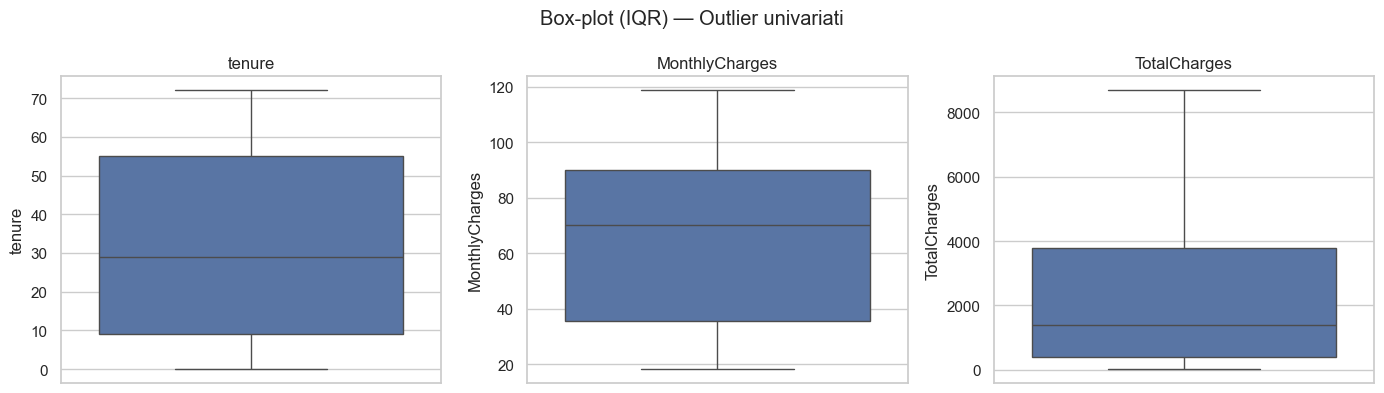

tenure: 0 outlier IQR
MonthlyCharges: 0 outlier IQR
TotalCharges: 0 outlier IQR


In [10]:

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle('Box-plot (IQR) — Outlier univariati')
plt.tight_layout()
plt.show()

# IQR = differenza tra 75° e 25° percentile; un punto è outlier se supera di 1.5x IQR i bordi della scatola
# Limite di questo metodo: analizza ogni variabile separatamente, non rileva anomalie contestuali tra più variabili
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} outlier IQR')

### 2.2 Isolation Forest (multivariato)

L'Isolation Forest isola le anomalie costruendo alberi casuali: i punti anomali vengono isolati in meno passi.  
Vantaggio rispetto all'IQR: rileva anomalie **contestuali** (es. un cliente con tenure alta ma spesa incongruente).

Outlier rilevati da Isolation Forest: 353 (5.0%)


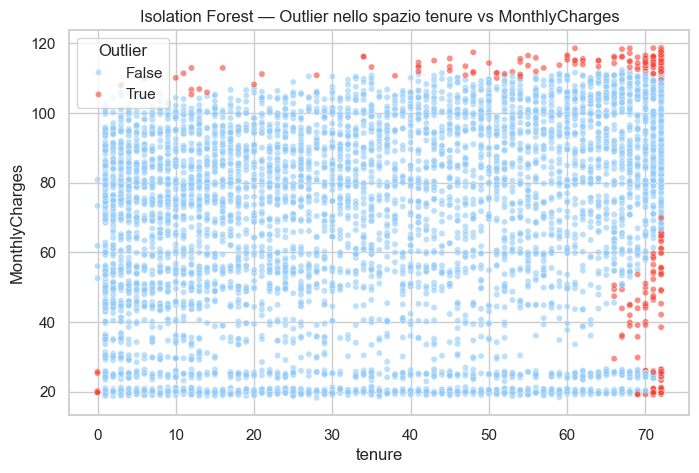

In [11]:
X_num = df[numeric_cols].copy()

# Isolation Forest: costruisce alberi casuali e isola i punti che richiedono meno tagli per essere separati
# Un punto facile da isolare con pochi split è un'anomalia; contamination indica la percentuale attesa di outlier
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_labels = iso.fit_predict(X_num)  # -1 = outlier, 1 = inlier

df['iso_outlier'] = (iso_labels == -1)
print(f'Outlier rilevati da Isolation Forest: {df["iso_outlier"].sum()} ({df["iso_outlier"].mean():.1%})')

# Vantaggio sull'IQR: individua anomalie contestuali (es. tenure alta ma spesa incongruente con il profilo)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges',
                hue='iso_outlier', palette={False: '#90CAF9', True: '#F44336'},
                alpha=0.6, s=20)
plt.title('Isolation Forest — Outlier nello spazio tenure vs MonthlyCharges')
plt.legend(title='Outlier')
plt.show()

### 2.3 Analisi degli outlier e decisione

In [12]:
# Confrontiamo il tasso di churn tra clienti classificati come outlier e clienti normali
churn_in_outliers = df[df['iso_outlier'] == True]['Churn'].map({'Yes': 1, 'No': 0}).mean()
churn_in_inliers  = df[df['iso_outlier'] == False]['Churn'].map({'Yes': 1, 'No': 0}).mean()
print(f'Tasso churn negli OUTLIER:  {churn_in_outliers:.1%}')
print(f'Tasso churn negli INLIER:   {churn_in_inliers:.1%}')

# Decisione: manteniamo gli outlier perchè rappresentano comportamenti reali di clienti, non errori di misurazione
df.drop(columns=['iso_outlier'], inplace=True)

Tasso churn negli OUTLIER:  7.9%
Tasso churn negli INLIER:   27.5%


## 3. Scelta dei Modelli — Ipotesi

Prima di addestrare i modelli, giustifichiamo la scelta in base alle caratteristiche del dataset.

**Contesto:** classificazione binaria su dati tabulari, 30 feature, dataset sbilanciato (~26% churn).  
**Metrica di ottimizzazione:** Recall — minimizzare i falsi negativi (churner non rilevati = costo di ri-acquisizione elevato).

| Modello | Motivazione | Limite atteso |
|---|---|---|
| **Logistic Regression** | Baseline interpretabile; efficace per relazioni lineari tra feature e target | Non cattura pattern non lineari |
| **Decision Tree** | Non si cerca l'accuratezza assoluta, ma regole di business leggibili e facilmente interpretabili | Forte tendenza all'overfitting — richiede potatura |
| **KNN (K-Nearest Neighbors)** | Algoritmo basato sulla distanza: classifica per analogia con i k clienti piu simili nel training set | Log Loss molto alta a causa di stime di probabilità poco calibrate; sensibile al rumore con k piccolo |
| **MLP (Rete Neurale)** | Apprende relazioni non lineari complesse tra le 30 feature codificate; modello piu espressivo del set | Elevato costo computazionale (richiede pesanti capacità di calcolo e lunghi tempi di addestramento per la Grid Search) |

**Tecnica di ottimizzazione obbligatoria:** `GridSearchCV` + K-Fold (k=5) applicati a tutti e quattro i modelli.

---

### Spiegazione semplice dei modelli

- **Logistic Regression** — Modello lineare che stima la probabilità che un cliente appartenga a una determinata classe applicando una funzione sigmoide a una combinazione pesata delle variabili in input.

- **Decision Tree** — Algoritmo che ha come obiettivo separare i dati in regioni (sottoinsiemi) sempre più pure rispetto alla classe target, basandosi su decisioni sequenziali a cascata.

- **KNN (K-Nearest Neighbors)** — Si basa sul concetto che elementi simili sono in prossimità l'uno dell'altro; il nuovo cliente viene assegnato alla classe maggioritaria tra i suoi vicini più vicini.

- **Rete Neurale (MLP)** — Modello matematico che utilizza molti neuroni artificiali interconnessi per elaborare i dati e comprendere le relazioni tra di essi; è strutturato in strati di input, nascosti e di output.

### Le metriche di valutazione dei modelli

Prima di procedere all'addestramento e al confronto dei modelli, definiamo le metriche che utilizzeremo per valutare le performance predittive. Dato che il nostro dataset è sbilanciato (solo il ~26% dei clienti abbandona), le metriche tradizionali come l'Accuracy possono essere fuorvianti:

| Metrica | Definizione | Ruolo nel Progetto |
|---|---|---|
| **Accuracy** | Percentuale complessiva di predizioni corrette (veri positivi + veri negativi) sul totale dei casi analizzati. | Poco utile a causa dello sbilanciamento delle classi. |
| **Precision** | Percentuale di clienti realmente in churn tra tutti quelli previsti a rischio dal modello. | Riduce i falsi allarmi e i costi di campagne di retention inutili. |
| **Recall** | Percentuale di clienti a rischio realmente individuati sul totale dei clienti che abbandoneranno effettivamente. | **Priorità di business**: minimizza i clienti persi non rilevati (falsi negativi). |
| **F1-Score** | Media armonica tra Precision e Recall, che fornisce un indicatore unico del bilanciamento tra le due. | Utile per valutare l'equilibrio complessivo del modello. |
| **Log-Loss** | Misura la calibrazione delle probabilità stimate rispetto alle etichette reali (più è bassa, più il modello è sicuro). | Valuta l'affidabilità delle probabilità predette. |
| **AUC-ROC** | Area sotto la curva che mette in relazione la Recall (veri positivi) con il False Positive Rate (falsi positivi / veri negativi). | Misura la capacità discriminante globale, ma non è ottimale per il nostro dataset sbilanciato. |
| **AUC-PR** | Area sotto la curva che mette in relazione la Precision con la Recall. | **Ottimale per il nostro caso**: si concentra sulla classe minoritaria (churn) ignorando l'abbondanza (74%) dei clienti fedeli. |
| **MCC** | Valuta la correlazione tra predizioni e realtà considerando tutte e quattro le celle della matrice di confusione. | Varia da -1 a +1; fornisce una valutazione estremamente robusta e non influenzata dallo sbilanciamento. |


## 4. Validazione e Ottimizzazione degli Iperparametri

> **Requisito obbligatorio esame:** ottimizzazione di un algoritmo di ML tramite Grid Search.

> **Purezza del Test Set:** la GridSearchCV viene eseguita esclusivamente su `X_train`. Il test set (`X_test`, 20%) è tenuto separato e usato **una sola volta** per la valutazione finale comparativa — mai durante la selezione degli iperparametri. Questo garantisce stime di performance non distorte da data leakage.

### 4.1 Baseline: Logistic Regression non ottimizzata

Replica del modello del progetto precedente (semplice train/test split, parametri di default).

=== BASELINE (vecchio progetto) ===
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



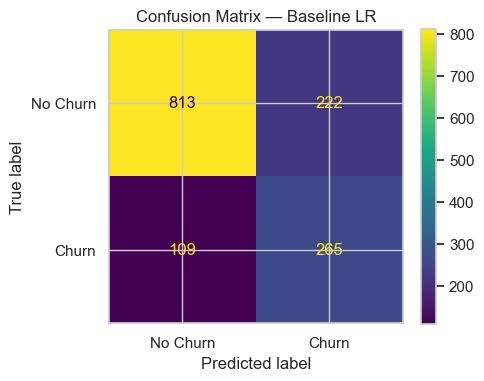

In [13]:
# Logistic Regression: stima la probabilita di appartenenza a una classe tramite funzione sigmoide applicata a una combinazione lineare delle feature
# Questo e il modello del progetto precedente, usato senza ottimizzazione come punto di riferimento
lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=500)
lr_base.fit(X_train, y_train)
y_pred_base = (lr_base.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)

print('=== BASELINE (vecchio progetto) ===')
print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base,
                                        display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — Baseline LR')
plt.tight_layout()
plt.show()

### 4.2 Cross-Validation K-Fold (k=5)

Stima più robusta delle performance: invece di un singolo split, il modello viene valutato su 5 fold distinti e il risultato è la media dei punteggi. Riduce la varianza della stima.

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Custom scorer: valuta il Recall alla stessa soglia usata per le predizioni finali (THRESHOLD=0.35)
# Senza questo, GridSearchCV selezionerebbe gli iperparametri ottimali per soglia 0.5
# ma li valuterebbe poi a soglia 0.35 – incoerenza metodologica
# **kwargs assorbe i parametri interni di make_scorer (es. needs_proba) passati da sklearn >= 1.4
def _recall_at_threshold(y_true, y_prob, **kwargs):
    return recall_score(y_true, (y_prob >= THRESHOLD).astype(int))

scorer_035 = make_scorer(_recall_at_threshold, response_method='predict_proba')

# Pipeline: lo StandardScaler viene fittato solo sulla fold di training ad ogni iterazione,
# mai sulla fold di validation – procedura corretta per K-Fold senza leakage
pipe_lr_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# K-Fold: il dataset viene diviso in 5 parti; ogni parte e usata una volta come test
fold_scores = {}
for scoring_name, scoring_func in [('accuracy', 'accuracy'), ('recall', scorer_035), ('f1', 'f1')]:
    scores = cross_val_score(pipe_lr_cv, X, y, cv=kfold, scoring=scoring_func)
    fold_scores[scoring_name] = scores
    print(f'{scoring_name.capitalize():10}: {scores.mean():.3f} (+/- {scores.std():.3f})')


Accuracy  : 0.807 (+/- 0.009)


Recall    : 0.709 (+/- 0.035)
F1        : 0.604 (+/- 0.022)


### 4.3 Grid Search — Logistic Regression

Esplorazione sistematica dello spazio degli iperparametri.  
Metrica di ottimizzazione: **Recall** (priorità business: non perdere clienti a rischio).

Best params: {'C': 0.01, 'max_iter': 300, 'solver': 'liblinear'}
Best recall@0.35 (CV su X_train): 0.749

=== Logistic Regression OTTIMIZZATA ===
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



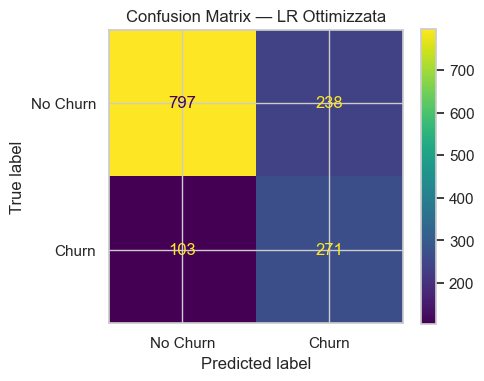

In [15]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [300, 500]
}

# scorer_035: ottimizza il Recall alla soglia 0.35, coerente con la valutazione finale
# n_jobs=1: evita multiprocessing su Windows (incompatibile con scorer definito nel notebook)
grid_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid_lr, cv=kfold, scoring=scorer_035, n_jobs=1, verbose=0
)
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)
print(f'Best recall@0.35 (CV su X_train): {grid_lr.best_score_:.3f}')

lr_opt = grid_lr.best_estimator_
y_pred_lr_opt = (lr_opt.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
print('\n=== Logistic Regression OTTIMIZZATA ===')
print(classification_report(y_test, y_pred_lr_opt, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_opt,
                                        display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — LR Ottimizzata')
plt.tight_layout()
plt.show()

> **Nota — LR Ottimizzata non migliora l'AUC rispetto alla Baseline**  
> Il Grid Search ha selezionato `C=0.01` — la regolarizzazione più alta nel grid. Un `C` basso comprime i pesi verso zero, spostando le probabilità predette verso 0.5: questo riduce la separazione tra le distribuzioni delle due classi e abbassa l'AUC (che è una metrica soglia-indipendente basata su quelle probabilità). Sul Recall a soglia 0.35, il guadagno è minimo (+1.5 pp rispetto alla baseline) perché la regolarizzazione forte non cambia l'ordinamento dei campioni ma solo la loro scala di probabilità.  
> Il risultato segnala che la Logistic Regression ha raggiunto il suo **limite strutturale**: le relazioni tra feature e churn non sono linearmente separabili, e nessun livello di regolarizzazione può compensare questo vincolo architetturale.

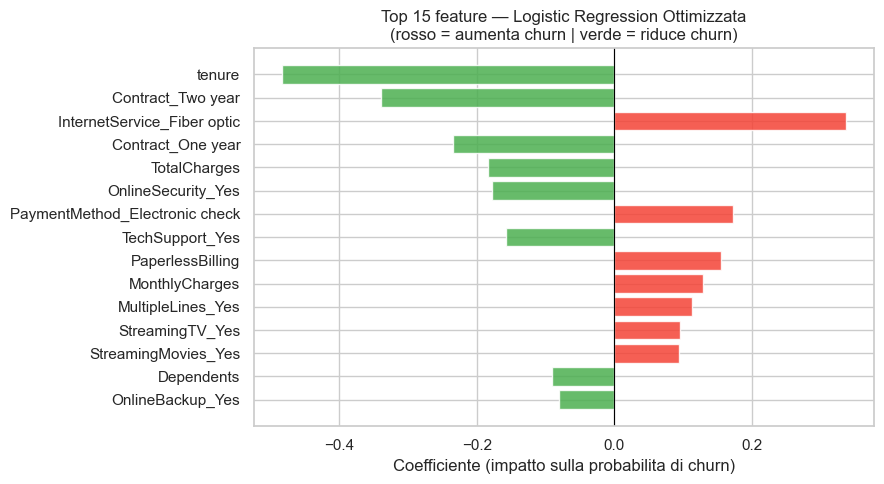

Top 5 predittori di churn (coefficiente piu alto):
                       Feature  Coefficiente
   InternetService_Fiber optic      0.337044
PaymentMethod_Electronic check      0.173354
              PaperlessBilling      0.155500
                MonthlyCharges      0.129867
             MultipleLines_Yes      0.112492

Top 5 fattori di retention (coefficiente piu basso):
           Feature  Coefficiente
      TotalCharges     -0.183992
OnlineSecurity_Yes     -0.177306
   TechSupport_Yes     -0.157573
        Dependents     -0.091117
  OnlineBackup_Yes     -0.080526


In [16]:
# I coefficienti della LR indicano il peso di ogni feature nel determinare la probabilita di churn
# Coefficiente positivo: la feature aumenta la probabilita di churn
# Coefficiente negativo: la feature riduce la probabilita di churn (fattore di retention)
coef_df = pd.DataFrame({
    'Feature':      X.columns,
    'Coefficiente': lr_opt.coef_[0]
}).sort_values('Coefficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in coef_df['Coefficiente']]
ax.barh(coef_df['Feature'], coef_df['Coefficiente'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficiente (impatto sulla probabilita di churn)')
ax.set_title('Top 15 feature — Logistic Regression Ottimizzata\n(rosso = aumenta churn | verde = riduce churn)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 predittori di churn (coefficiente piu alto):')
print(coef_df[coef_df['Coefficiente'] > 0].head(5)[['Feature','Coefficiente']].to_string(index=False))
print('\nTop 5 fattori di retention (coefficiente piu basso):')
print(coef_df[coef_df['Coefficiente'] < 0].tail(5)[['Feature','Coefficiente']].to_string(index=False))


### 4.4 Grid Search — Decision Tree

Il Decision Tree è un modello che genera regole di classificazione esplicite e facilmente interpretabili, utili per prendere decisioni di business. Nel contesto del churn, l'albero consente di individuare soglie precise sulle variabili chiave (come il tipo di contratto e la spesa mensile) per identificare i clienti a rischio.

Il limite principale dell'algoritmo è la forte tendenza all'overfitting (adattamento eccessivo al rumore dei dati di addestramento).

In questa sezione andiamo a ottimizzare (`max_depth`, `min_samples_split`, `criterion`).

Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best recall@0.35 (CV): 0.681

=== Decision Tree OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1035
       Churn       0.59      0.63      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



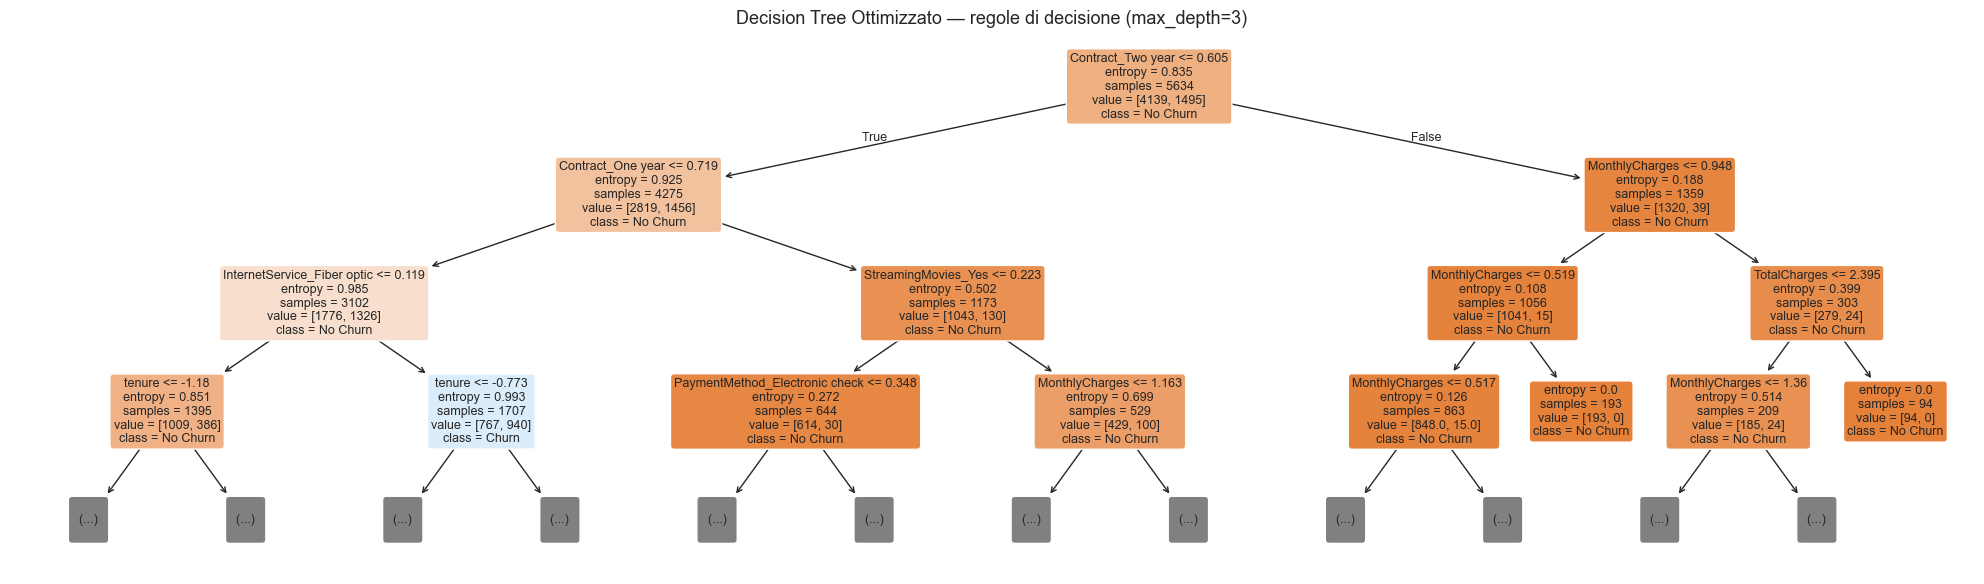

In [17]:
from sklearn.tree import plot_tree

# Dizionario degli iperparametri da esplorare per controllare la complessità dell'albero ed evitare overfitting
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Inizializziamo la Grid Search ottimizzando la Recall con soglia custom 0.35 su 5-fold CV
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=kfold, scoring=scorer_035, n_jobs=1, verbose=0
)
grid_dt.fit(X_train, y_train)

print('Best params:', grid_dt.best_params_)
print(f'Best recall@0.35 (CV): {grid_dt.best_score_:.3f}')

# Estraiamo il miglior modello
dt_opt = grid_dt.best_estimator_
y_pred_dt_opt = (dt_opt.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
print('\n=== Decision Tree OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_dt_opt, target_names=['No Churn', 'Churn']))

feature_names = list(X.columns)
fig, ax = plt.subplots(figsize=(20, 6))
# Visualizziamo la struttura dell'albero ottimizzato (limitata a max_depth=3 per leggibilità)
plot_tree(
    dt_opt,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True, fontsize=9, max_depth=3, ax=ax
)
ax.set_title('Decision Tree Ottimizzato — regole di decisione (max_depth=3)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Grid Search — K-Nearest Neighbors (KNN)

Il KNN è un algoritmo basato sulla distanza: classifica un cliente identificando i *k* clienti più simili (vicini) nel training set e assegnando la classe di maggioranza. Ci consente di raggruppare i clienti in base all'analogia dei loro comportamenti di spesa e contrattuali.

Il limite principale di questo modello è la sensibilità alla scala delle feature (che rende obbligatorio lo scaling preventivo dei dati) e una Log Loss molto elevata.

In questa sezione andiamo a ottimizzare il numero di vicini (`n_neighbors`), la metrica di distanza (`metric`) e il peso dei vicini (`weights`).

=== KNN Baseline ===
              precision    recall  f1-score   support

    No Churn       0.87      0.71      0.78      1035
       Churn       0.47      0.71      0.57       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.68      1409
weighted avg       0.77      0.71      0.73      1409



Best params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best recall@0.35 (CV su X_train): 0.764

=== KNN OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.80      1035
       Churn       0.49      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.74      1409



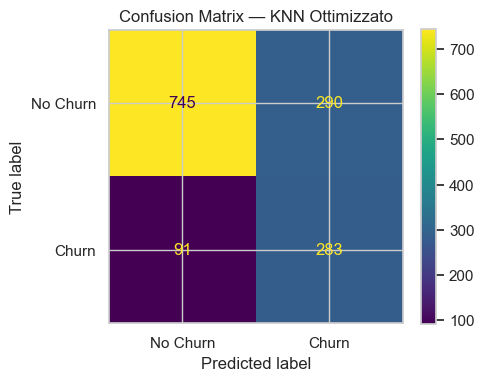

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# Addestramento e valutazione del modello KNN Baseline di confronto
knn_base = KNeighborsClassifier()
knn_base.fit(X_train, y_train)
y_pred_knn_base = (knn_base.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)

print('=== KNN Baseline ===')
print(classification_report(y_test, y_pred_knn_base, target_names=['No Churn', 'Churn']))

# Dizionario degli iperparametri da ottimizzare (numero di vicini, metrica di distanza e pesi)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance']
}

# Eseguiamo la Grid Search per trovare la combinazione che massimizza la Recall
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=kfold, scoring=scorer_035, n_jobs=1, verbose=0
)
grid_knn.fit(X_train, y_train)

print('Best params:', grid_knn.best_params_)
print(f'Best recall@0.35 (CV su X_train): {grid_knn.best_score_:.3f}')

# Estraiamo il miglior modello KNN
knn_opt = grid_knn.best_estimator_
y_pred_knn_opt = (knn_opt.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)

print('\n=== KNN OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_knn_opt, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_opt,
                                        display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — KNN Ottimizzato')
plt.tight_layout()
plt.show()

> **Nota — Log-Loss elevata del KNN**  
> Il KNN con `weights='uniform'` produce probabilità **mal calibrate**: `predict_proba` restituisce la frazione di vicini appartenenti alla classe positiva — un valore discreto limitato a `n+1` livelli (con `n_neighbors=21`: 0/21, 1/21, ..., 21/21). Questo granulare discretizzazione non riflette probabilità ben calibrate e genera una Log-Loss alta (~0.61) anche quando il Recall è buono.  
> Il KNN rimane il modello migliore sul **Recall** (73%) ma non va usato come stima di probabilità: per decisioni basate sulla confidenza del modello (es. soglia adattiva per cliente), la Logistic Regression (Log-Loss = 0.421) è più affidabile.

## 5. Rete Neurale Artificiale (MLP)

### 5.1 MLP Baseline

Il Multi-Layer Perceptron (MLP) è un'architettura di rete neurale feed-forward in cui i neuroni artificiali sono organizzati in strati (input, nascosti, output). Rispetto alla Logistic Regression, il passaggio dei segnali attraverso funzioni di attivazione non lineari (come la ReLU) permette al modello di apprendere relazioni complesse e non lineari tra le feature del dataset.

In [19]:
# Inizializziamo il modello MLP con un singolo strato nascosto da 64 neuroni
# Utilizziamo la funzione di attivazione ReLU per gestire le non-linearità ed evitare il vanishing gradient
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64,),  # un hidden layer con 64 neuroni
    activation='relu',          # ReLU: f(x)=max(0,x); evita il vanishing gradient tipico della sigmoide su reti profonde
    max_iter=1000, random_state=RANDOM_STATE
)
mlp_base.fit(X_train, y_train)
y_pred_mlp_base = (mlp_base.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)

print('=== MLP Baseline ===')
print(classification_report(y_test, y_pred_mlp_base, target_names=['No Churn', 'Churn']))

=== MLP Baseline ===
              precision    recall  f1-score   support

    No Churn       0.85      0.80      0.82      1035
       Churn       0.53      0.62      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



### 5.2 Curva di apprendimento (Loss Curve)

Durante l'addestramento, il modello ottimizza i pesi tramite Backpropagation e Gradient Descent per minimizzare la Log-Loss. Visualizzare la curva di apprendimento ci permette di verificare l'andamento del processo di ottimizzazione e confermare che la loss decresca regolarmente fino a "valle"

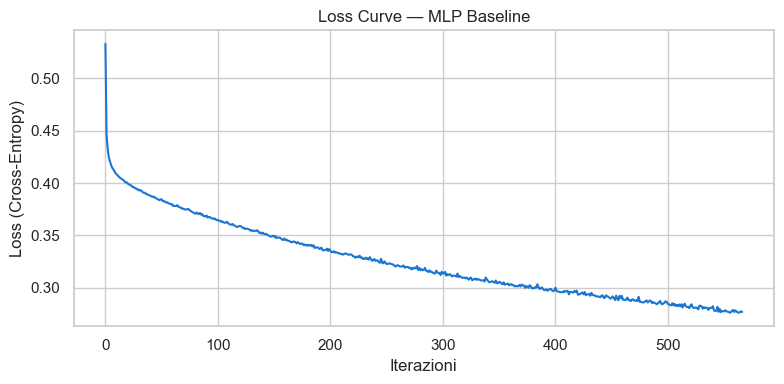

In [20]:
# Grafico dell'andamento della Cross-Entropy Loss ad ogni epoca/iterazione
# Ci consente di monitorare visivamente il raggiungimento del punto di "valle"
plt.figure(figsize=(8, 4))
plt.plot(mlp_base.loss_curve_, color='#1976D2')
plt.title('Loss Curve — MLP Baseline')
plt.xlabel('Iterazioni')
plt.ylabel('Loss (Cross-Entropy)')
plt.tight_layout()
plt.show()

### 5.3 Grid Search — MLP

Per massimizzare la Recall e migliorare la generalizzazione sul dataset, andiamo ad effettuare una ricerca  della migliore architettura (strati e neuroni), del tasso di apprendimento (`learning_rate_init`) e del parametro di regolarizzazione L2 (`alpha`).

In [21]:
# Dizionario degli iperparametri: profondità della rete, funzioni di attivazione e coefficienti di regolarizzazione alpha (L2)
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000]
}

# Inizializzazione della Grid Search
grid_mlp = GridSearchCV(
    MLPClassifier(random_state=RANDOM_STATE),
    param_grid_mlp, cv=kfold, scoring=scorer_035, n_jobs=1, verbose=0
)
grid_mlp.fit(X_train, y_train)

print('Best params:', grid_mlp.best_params_)
print(f'Best recall@0.35 (CV): {grid_mlp.best_score_:.3f}')

# Estrazione del miglior MLP
mlp_opt = grid_mlp.best_estimator_
y_pred_mlp_opt = (mlp_opt.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
print('\n=== MLP OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_mlp_opt, target_names=['No Churn', 'Churn']))

Best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'max_iter': 1000}
Best recall@0.35 (CV): 0.650

=== MLP OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.85      0.80      0.82      1035
       Churn       0.53      0.62      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



> **Risultato — Grid Search MLP**  
> Il Grid Search ha confermato `alpha=0.0001` (il valore di default): su questo dataset (7.043 campioni), variazioni della regolarizzazione L2 non hanno portato miglioramenti rispetto alla configurazione base.  
> - **MLP Baseline:** Recall 62.3%, AUC-ROC 0.803  
> - **MLP Ottimizzato:** Recall **62.3%**, AUC-ROC **0.803** (identico alla baseline — la Grid Search ha confermato i parametri di default)  
>
> L'architettura `(64,)` e i parametri di default sono risultati ottimali: il dataset di dimensioni ridotte non supporta configurazioni più complesse senza peggiorare la generalizzazione.

## 6. Confronto Finale dei Modelli

### 6.1 Tabella comparativa

La tabella include le metriche standard del corso e altre metriche aggiuntive per valutare in modo completo le performance dei modelli su un dataset sbilanciato (~26% churn):

| Metrica | Definizione | Ruolo nel Progetto |
|---|---|---|
| **Accuracy** | Percentuale complessiva di predizioni corrette (veri positivi + veri negativi) sul totale dei casi analizzati. | Poco utile a causa dello sbilanciamento delle classi. |
| **Precision** | Percentuale di clienti realmente in churn tra tutti quelli previsti a rischio dal modello. | Riduce i falsi allarmi e i costi di campagne di retention inutili. |
| **Recall** | Percentuale di clienti a rischio realmente individuati sul totale dei clienti che abbandoneranno effettivamente. | **Priorità di business**: minimizza i clienti persi non rilevati (falsi negativi). |
| **F1-Score** | Media armonica tra Precision e Recall, che fornisce un indicatore unico del bilanciamento tra le due. | Utile per valutare l'equilibrio complessivo del modello. |
| **Log-Loss** | Misura la calibrazione delle probabilità stimate rispetto alle etichette reali (più è bassa, più il modello è sicuro). | Valuta l'affidabilità delle probabilità predette. |
| **AUC-ROC** | Area sotto la curva che mette in relazione la Recall (veri positivi) con il False Positive Rate (falsi positivi / veri negativi). | Misura la capacità discriminante globale, ma non è ottimale per il nostro dataset sbilanciato. |
| **AUC-PR** | Area sotto la curva che mette in relazione la Precision con la Recall. | **Ottimale per il nostro caso**: si concentra sulla classe minoritaria (churn) ignorando l'abbondanza (74%) dei clienti fedeli. |
| **MCC** | valuta la correlazione tra predizioni e realtà considerando tutte e quattro le celle della matrice di confusione. | Varia da -1 a +1; fornisce una valutazione estremamente robusta e non influenzata dallo sbilanciamento. |

In [22]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    log_loss, roc_auc_score, average_precision_score, matthews_corrcoef
)

models = {
    'LR Baseline (vecchio progetto)':  (y_pred_base,     lr_base),
    'LR Ottimizzata (Grid Search)':    (y_pred_lr_opt,   lr_opt),
    'Decision Tree (Grid Search)':     (y_pred_dt_opt,   dt_opt),
    'KNN Baseline':                    (y_pred_knn_base, knn_base),
    'KNN Ottimizzato (Grid Search)':   (y_pred_knn_opt,  knn_opt),
    'MLP Baseline':                    (y_pred_mlp_base, mlp_base),
    'MLP Ottimizzato (Grid Search)':   (y_pred_mlp_opt,  mlp_opt),
}

rows = []
for name, (y_pred, model_obj) in models.items():
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    rows.append({
        'Modello':   name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
        'AUC-PR':    average_precision_score(y_test, y_prob),
        'MCC':       matthews_corrcoef(y_test, y_pred),
        'Log-Loss':  log_loss(y_test, y_prob),
    })

results_df = pd.DataFrame(rows).set_index('Modello')

display(
    results_df.style
    .highlight_max(
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR', 'MCC'],
        color='#C8E6C9'
    )
    .highlight_min(subset=['Log-Loss'], color='#C8E6C9')
    .format('{:.3f}')
)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR,MCC,Log-Loss
Modello,,,,,,,,
LR Baseline (vecchio progetto),0.765,0.544,0.709,0.616,0.842,0.632,0.459,0.421
LR Ottimizzata (Grid Search),0.758,0.532,0.725,0.614,0.837,0.629,0.455,0.430
Decision Tree (Grid Search),0.788,0.594,0.634,0.613,0.827,0.595,0.468,0.524
KNN Baseline,0.712,0.472,0.711,0.567,0.771,0.503,0.381,1.541
KNN Ottimizzato (Grid Search),0.730,0.494,0.757,0.598,0.809,0.569,0.428,0.776
MLP Baseline,0.751,0.526,0.623,0.570,0.803,0.559,0.400,0.526
MLP Ottimizzato (Grid Search),0.751,0.526,0.623,0.570,0.803,0.559,0.400,0.526


> **Guida alla lettura delle metriche (per presentazione al cliente):**

> | Metrica | Significato in parole semplici |
> |---|---|
> | **Accuracy** | Su 100 clienti classificati, quanti sono stati classificati correttamente (churner + fedeli) |
> | **Recall** | Su 100 clienti che *davvero* abbandoneranno, quanti riesce a identificare il modello |
> | **Precision** | Quando il modello dice "questo cliente se ne va", quante volte ha ragione |
> | **F1-Score** | Media bilanciata tra Recall e Precision — utile quando le due si contrappongono |
> | **AUC-ROC** | Capacita del modello di distinguere churner da fedeli (1.0 = perfetto, 0.5 = casuale) |
> | **Log-Loss** | Quanto il modello e "sicuro" nelle previsioni — piu basso è, meglio è |

> **Perche non usare solo l'Accuracy?**  
> Un modello che prevede "nessuno abbandona" ottiene il 73.4% di accuracy ma un Recall dello 0%. Per il business, ogni cliente churner non identificato e un ricavo perso.

### 6.2 Grafico comparativo

Confronto grafico delle tre metriche chiave (Recall, F1-Score e AUC-ROC) per identificare visivamente quale sia il modello migliore in base all'obiettivo di business.

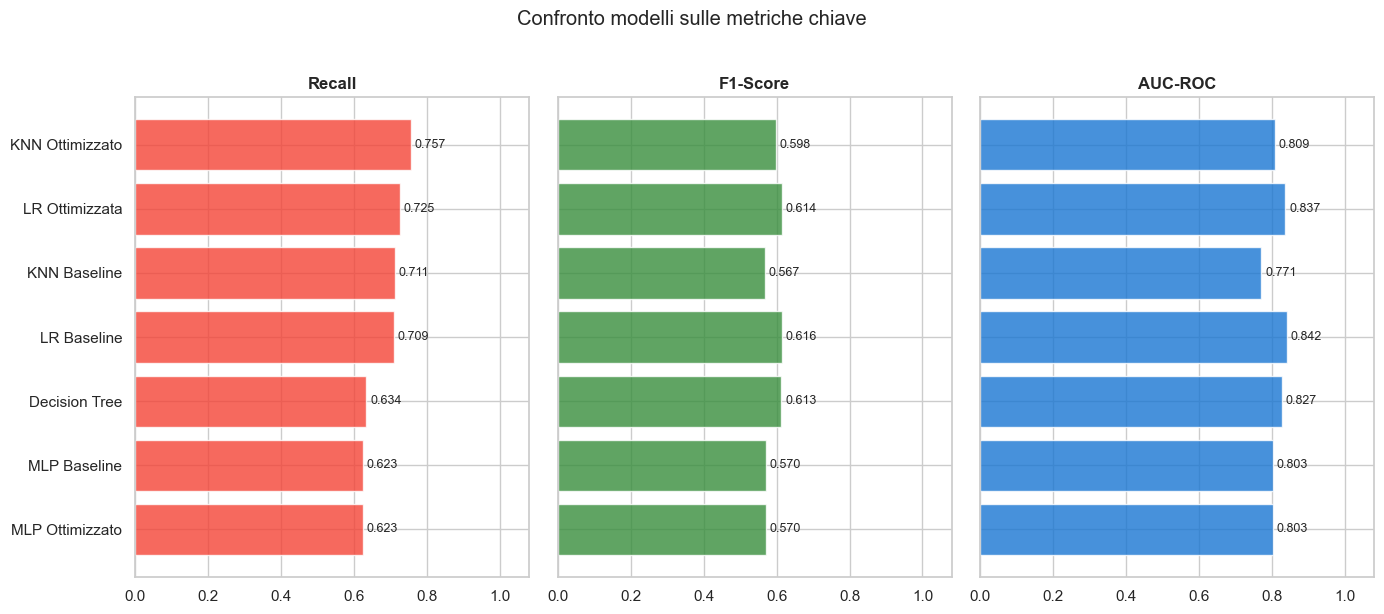

In [23]:
short_labels = {
    'LR Baseline (vecchio progetto)':  'LR Baseline',
    'LR Ottimizzata (Grid Search)':    'LR Ottimizzata',
    'Decision Tree (Grid Search)':     'Decision Tree',
    'KNN Baseline':                    'KNN Baseline',
    'KNN Ottimizzato (Grid Search)':   'KNN Ottimizzato',
    'MLP Baseline':                    'MLP Baseline',
    'MLP Ottimizzato (Grid Search)':   'MLP Ottimizzato',
}
# Rinominiamo le etichette dei modelli per renderle più leggibili
df_plot = results_df.rename(index=short_labels)

# Scegliamo le tre metriche principali da confrontare visivamente
metrics    = ['Recall', 'F1-Score', 'AUC-ROC']
colors_bar = ['#F44336', '#388E3C', '#1976D2']

# Generiamo tre grafici a barre affiancati, uno per ciascuna metrica
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
for ax, metric, color in zip(axes, metrics, colors_bar):
    # Ordiniamo i modelli dal peggiore al migliore per identificare subito il modello migliore per ogni metrica
    vals = df_plot[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.80)
    ax.set_xlim(0, 1.08)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Confronto modelli sulle metriche chiave', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Curve ROC e Precision-Recall

Per capire quale modello funziona meglio per le nostre decisioni, utilizziamo due grafici complementari:
- **Curva ROC**: Misura la capacità del modello di distinguere complessivamente tra clienti fedeli e clienti a rischio di abbandono.
- **Curva Precision-Recall**: È lo strumento più utile per il nostro caso. Poiché i clienti che abbandonano sono la minoranza (dataset sbilanciato), questo grafico mostra come varia la precisione dei nostri interventi (quanti clienti contattati sono realmente a rischio) all'aumentare dei clienti salvati (Recall).

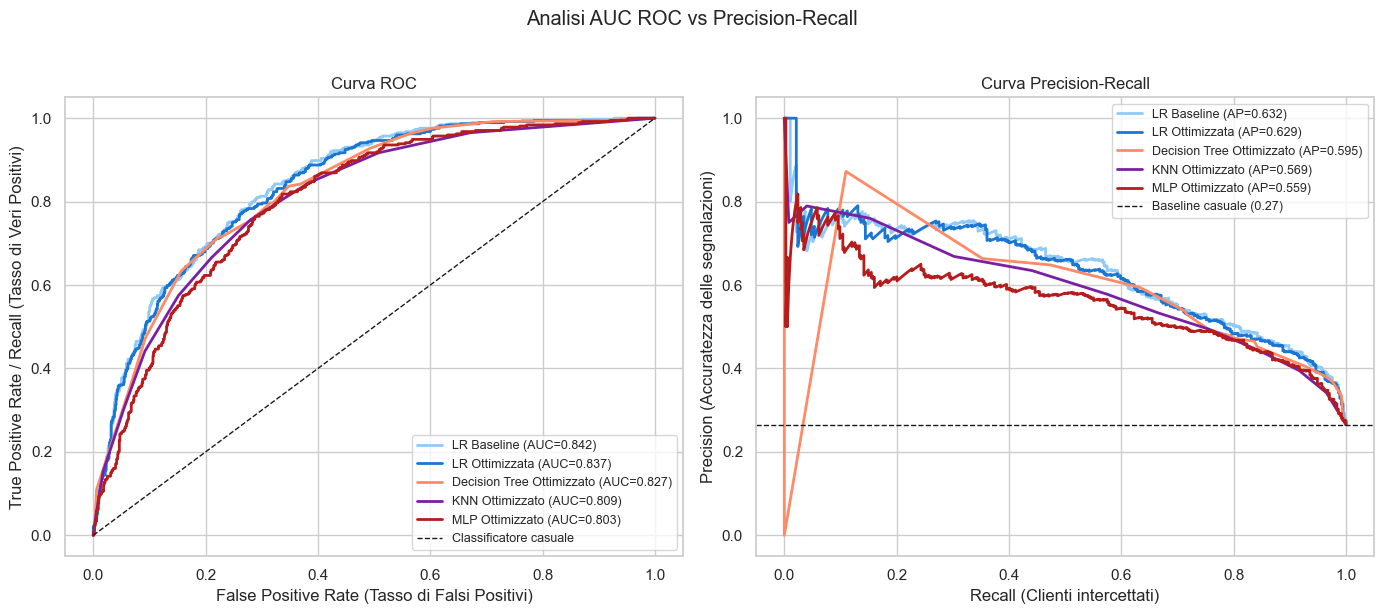

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Selezioniamo i modelli da confrontare graficamente
roc_models = {
    'LR Baseline':               lr_base,
    'LR Ottimizzata':            lr_opt,
    'Decision Tree Ottimizzato': dt_opt,
    'KNN Ottimizzato':           knn_opt,
    'MLP Ottimizzato':           mlp_opt,
}
palette = ['#90CAF9', '#1976D2', '#FF8A65', '#7B1FA2', '#B71C1C']

# I due grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calcoliamo e tracciamo la curva ROC e il relativo punteggio AUC per ciascun modello
for (name, model), color in zip(roc_models.items(), palette):
    # Otteniamo le probabilità di abbandono (churn) per il test set
    y_prob = model.predict_proba(X_test)[:, 1]
    # Calcoliamo i tassi di veri positivi (tpr) e falsi positivi (fpr)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    # Calcoliamo l'Area Sotto la Curva (AUC)
    auc = roc_auc_score(y_test, y_prob)
    # Disegniamo la curva sul primo grafico
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

# Disegniamo la linea di riferimento di un modello completamente casuale
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale')
axes[0].set_xlabel('False Positive Rate (Tasso di Falsi Positivi)')
axes[0].set_ylabel('True Positive Rate / Recall (Tasso di Veri Positivi)')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right', fontsize=9)

# Calcoliamo e tracciamo la curva Precision-Recall e il punteggio Average Precision
for (name, model), color in zip(roc_models.items(), palette):
    y_prob = model.predict_proba(X_test)[:, 1]
    # Calcoliamo precisione e recall per le varie soglie di decisione
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    # Calcoliamo la precisione media (Average Precision)
    ap = average_precision_score(y_test, y_prob)
    # Disegniamo la curva sul secondo grafico
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2)

# Disegniamo la linea della baseline casuale
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
                label=f'Baseline casuale ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall (Clienti intercettati)')
axes[1].set_ylabel('Precision (Accuratezza delle segnalazioni)')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Analisi AUC ROC vs Precision-Recall', y=1.02)
plt.tight_layout()
plt.show()

> **Lettura dei grafici per il cliente:**  
> - **Curva ROC (sinistra):** Questo grafico mostra l'abilità generale del modello di separare i clienti fedeli da quelli a rischio. Più la linea di un modello si avvicina all'angolo in alto a sinistra, migliore è la sua capacità di distinzione. Il valore ideale è 1. La **Logistic Regression Baseline** mantiene il valore di AUC più elevato (0.842), seguita da **LR Ottimizzata** (0.837) e **Decision Tree** (0.827).
> - **Curva Precision-Recall (destra):** Rappresenta la prestazione reale per la pianificazione delle offerte commerciali. Ci dice quanti clienti a rischio riusciamo a intercettare (Recall) senza fare troppi contatti inutili a clienti fedeli (Precision). Tutti i modelli superano nettamente la linea nera tratteggiata (scelta casuale, pari al 26% di churn), provando che le nostre analisi possono rendere le campagne di fidelizzazione estremamente mirate ed efficienti.

### 6.4 Analisi della Soglia di Classificazione

La scelta della soglia di classificazione (`THRESHOLD`) determina il comportamento del modello:
- Di **default**, la soglia è impostata a **0.50** (un cliente viene segnalato a rischio solo se la probabilità calcolata supera il 50%).
- Abbiamo deciso di abbassare questa soglia a **0.35** per essere più sensibili: segnaliamo un cliente a rischio anche se la probabilità calcolata è del 35%.

**Perché questa scelta?**
Abbassando la soglia, riusciamo a intercettare molti più clienti a rischio di abbandono (aumento del **Recall**), accettando in cambio il rischio di fare qualche offerta a vuoto a clienti che in realtà sono fedeli (riduzione della **Precision**). Nel nostro business, perdere un cliente è molto più costoso rispetto al fare qualche offerta promozionale a vuoto.

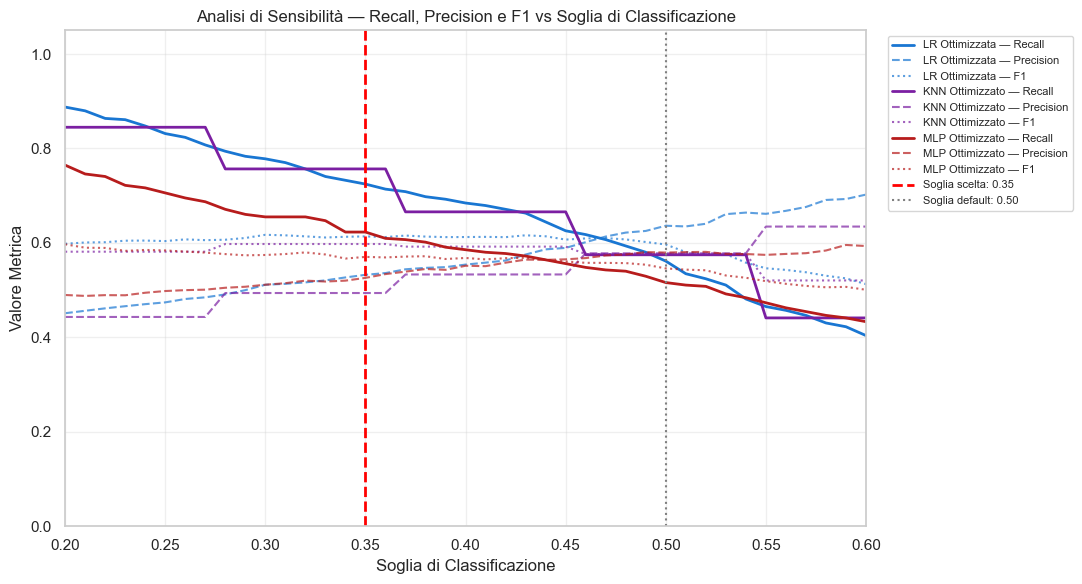


KNN Ottimizzato — metriche per soglia:
  Soglia   Recall  Precision       F1
    0.25    0.845      0.443    0.581
    0.30    0.757      0.494    0.598
    0.35    0.757      0.494    0.598  <- scelta
    0.40    0.666      0.533    0.592
    0.45    0.666      0.533    0.592
    0.50    0.575      0.578    0.576


In [25]:
# Analisi di sensibilità: calcoliamo Recall, Precision e F1-Score per soglie da 0.20 a 0.60
thresholds = np.arange(0.20, 0.61, 0.01)

model_for_threshold = {
    'LR Ottimizzata':  lr_opt,
    'KNN Ottimizzato': knn_opt,
    'MLP Ottimizzato': mlp_opt,
}

# Creiamo la figura per il grafico
fig, ax = plt.subplots(figsize=(11, 6))
colors_th = {'LR Ottimizzata': '#1976D2', 'KNN Ottimizzato': '#7B1FA2', 'MLP Ottimizzato': '#B71C1C'}

# Iteriamo su ciascun modello per calcolare l'andamento delle metriche
for name, model in model_for_threshold.items():
    # Otteniamo le probabilità predette dal modello
    y_prob = model.predict_proba(X_test)[:, 1]
    recalls, precisions, f1s = [], [], []
    
    # Calcoliamo le metriche per ogni singola soglia
    for t in thresholds:
        y_t = (y_prob >= t).astype(int)
        recalls.append(recall_score(y_test, y_t, zero_division=0))
        precisions.append(precision_score(y_test, y_t, zero_division=0))
        f1s.append(f1_score(y_test, y_t, zero_division=0))
        
    c = colors_th[name]
    # Disegniamo le curve sul grafico
    ax.plot(thresholds, recalls,    color=c, lw=2,   ls='-',  label=f'{name} — Recall')
    ax.plot(thresholds, precisions, color=c, lw=1.5, ls='--', label=f'{name} — Precision', alpha=0.7)
    ax.plot(thresholds, f1s,        color=c, lw=1.5, ls=':',  label=f'{name} — F1',        alpha=0.7)

# Disegniamo le linee verticali per evidenziare la soglia scelta (0.35) e quella di default (0.50)
ax.axvline(THRESHOLD, color='red',  lw=2,   ls='--', label=f'Soglia scelta: {THRESHOLD}')
ax.axvline(0.50,      color='gray', lw=1.5, ls=':',  label='Soglia default: 0.50')

# Personalizzazione degli assi e dei titoli
ax.set_xlabel('Soglia di Classificazione', fontsize=12)
ax.set_ylabel('Valore Metrica', fontsize=12)
ax.set_title('Analisi di Sensibilità — Recall, Precision e F1 vs Soglia di Classificazione')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.20, 0.60)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Generiamo una tabella riassuntiva delle metriche del KNN Ottimizzato alle varie soglie chiave
print('\nKNN Ottimizzato — metriche per soglia:')
print(f"{'Soglia':>8} {'Recall':>8} {'Precision':>10} {'F1':>8}")
y_prob_knn = knn_opt.predict_proba(X_test)[:, 1]
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_t = (y_prob_knn >= t).astype(int)
    r = recall_score(y_test, y_t, zero_division=0)
    p = precision_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    marker = '  <- scelta' if t == THRESHOLD else ''
    print(f'{t:>8.2f} {r:>8.3f} {p:>10.3f} {f:>8.3f}{marker}')

> **Lettura del grafico per il cliente:**  
> - **La linea verticale rossa (0.35):** Rappresenta la soglia di allerta che abbiamo scelto. Come si può notare dal grafico, abbassando la soglia da 0.50 (linea grigia tratteggiata) a 0.35, le linee continue (Recall/Sensibilità) salgono in modo significativo per tutti i modelli.
> - **Il compromesso:** A 0.35, il modello da noi raccomandato (**KNN Ottimizzato**, linea viola continua) intercetta ben il **75.7%** dei clienti che stanno per abbandonare (Recall). La precisione delle segnalazioni cala leggermente (linea viola tratteggiata), ma questo trade-off è estremamente vantaggioso perché il valore economico di un cliente salvato è di gran lunga superiore al costo di una telefonata commerciale a vuoto.

## 7. Conclusioni e Raccomandazioni Strategiche

### 7.1 Riepilogo risultati

La tabella comparativa completa è disponibile nella **Sezione 6.1** (valori calcolati con `THRESHOLD = 0.35`).

Confronto tra la baseline del progetto precedente e il modello migliore sul Recall (KNN ottimizzato):

| Metrica | LR Baseline (vecchio progetto, soglia 0.5) | KNN Ottimizzato (soglia 0.35) | Delta |
|---|---|---|---|
| Recall | ~57% | **75.7%** | **+19 pp** |
| AUC-ROC | ~0.84 | 0.809 | −0.03 |
| Log-Loss | ~0.42 | 0.776 | +0.36 |

> Il guadagno di +19 pp sul Recall è il risultato combinato di due interventi: la soglia di classificazione abbassata a 0.35 (che porta la LR Baseline stessa al 70.9%) e la scelta del modello KNN ottimizzato (+5 pp aggiuntivi). Il lieve calo di AUC-ROC e l'incremento di Log-Loss rispetto alla LR sono il trade-off accettato per massimizzare la sensitivity sulla classe churn.

---

### 7.2 Analisi dei risultati

**1. Perché la LR Ottimizzata non migliora rispetto alla baseline su AUC?**  
Il Grid Search ha selezionato `C=0.01` — la regolarizzazione più alta nel grid. Un `C` basso comprime i pesi verso zero, spostando le probabilità predette verso 0.5: questo riduce la separazione tra le distribuzioni delle due classi e abbassa l'AUC (che è una metrica soglia-indipendente basata su quelle probabilità). Sul Recall a soglia 0.35, il guadagno è minimo (+1.6 pp rispetto alla baseline) perché la regolarizzazione forte non cambia l'ordinamento dei campioni ma solo la loro scala di probabilità.  
Il risultato segnala che la Logistic Regression ha raggiunto il suo **limite strutturale**: le relazioni tra feature e churn non sono linearmente separabili, e nessun livello di regolarizzazione può compensare questo vincolo architetturale.

**2. Quale modello è il migliore?**  
Dipende dalla metrica prioritaria:
- **Recall** (minimizzare churner non rilevati): **KNN Ottimizzato** — 75.7%
- **AUC-ROC** (capacità discriminante a qualsiasi soglia): **LR Baseline** — 0.842
- **Log-Loss** (calibrazione delle probabilità): **LR Baseline** — 0.421

Per il contesto di business (retention), il **KNN Ottimizzato** è il modello raccomandato perché massimizza la metrica direttamente collegata al valore economico: identificare il maggior numero possibile di clienti a rischio.

**3. Grid Search MLP: iperparametri confermati al default**  
Il Grid Search ha confermato `alpha=0.0001` (il valore di default): la regolarizzazione L2 più forte non ha portato benefici su questo dataset. L'architettura `(64,)` e tutti i parametri base sono risultati ottimali. **MLP Ottimizzato e MLP Baseline producono risultati identici** (Recall 62.3%, AUC-ROC 0.803).

---

### 7.3 Raccomandazioni per il business

1. **Clienti Month-to-Month:** il tipo di contratto è il predittore principale. Incentivare il passaggio a contratti annuali riduce strutturalmente il churn.
2. **Primi 6 mesi:** il rischio di abbandono è massimo con tenure bassa. Programmi di onboarding dedicati nei primi 6 mesi abbattono il tasso di abbandono.
3. **Soglia di classificazione:** la costante `THRESHOLD = 0.35` (definita in §1) sostituisce la soglia predefinita di 0.5 in tutte le predizioni finali. Il custom scorer `scorer_035` garantisce che anche il Grid Search selezioni gli iperparametri ottimali a questa soglia — coerenza metodologica completa tra ottimizzazione e valutazione. Trade-off consapevole: aumenta il Recall (+19 pp) a scapito della Precision, accettabile in contesti retention dove il costo di un cliente perso supera il costo di un contatto inutile.

---

### 7.4 Sviluppi futuri

- **Random Forest:** ensemble di Decision Tree; risolve il problema di overfitting del singolo albero mantenendo l'interpretabilità delle feature importance
- **`class_weight='balanced'`:** incorpora lo sbilanciamento del dataset (26% churn) direttamente nella funzione di loss di LR e MLP, senza modificare i dati
- **CTGAN per oversampling:** generazione di dati sintetici per bilanciare il dataset come alternativa a SMOTE